In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
# Definición de las matrices de pagos (Forma Normal)
# Filas: Firma 1 | Columnas: Firma 2
U1 = np.array([
    [4, 2, 0],
    [5, 5, -1],
    [3, 1, -2]
])
 
U2 = np.array([
    [3, 7, 4],
    [5, 6, 4],
    [5, 5, 6]
])
 
estrategias = ["Baja", "Media", "Alta"]
 
# Sistema de creencias de la Firma 1 sobre la Firma 2
creencias_F2 = np.array([0.2, 0.5, 0.3])
 
# Cálculo del pago esperado: Producto punto de U1 por el vector de creencias
pagos_esperados_F1 = U1.dot(creencias_F2)
 
print("Pagos Esperados bajo Incertidumbre (Firma 1):")
for i, pago in enumerate(pagos_esperados_F1):
    print(f"Estrategia '{estrategias[i]}': ${pago:.2f} millones")
 
mejor_estrategia = np.argmax(pagos_esperados_F1)
print(f"\n-> La mejor respuesta de la Firma 1 es la inversión '{estrategias[mejor_estrategia]}'.")

Pagos Esperados bajo Incertidumbre (Firma 1):
Estrategia 'Baja': $1.80 millones
Estrategia 'Media': $3.20 millones
Estrategia 'Alta': $0.50 millones

-> La mejor respuesta de la Firma 1 es la inversión 'Media'.


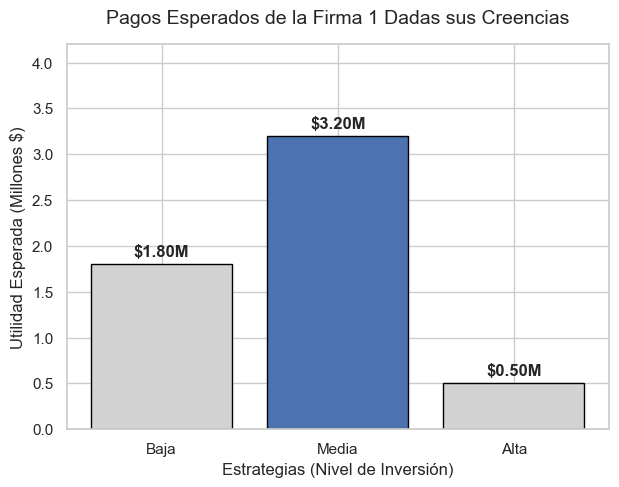

In [4]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(7, 5))
 
# Crear gráfico de barras
colores = ['#d3d3d3', '#4c72b0', '#d3d3d3'] # Resaltar la mejor opción
barras = plt.bar(estrategias, pagos_esperados_F1, color=colores, edgecolor='black')
 
# Añadir etiquetas de datos
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura + 0.05,
             f'${altura:.2f}M',
             ha='center', va='bottom', fontweight='bold')
 
plt.title('Pagos Esperados de la Firma 1 Dadas sus Creencias', fontsize=14, pad=15)
plt.xlabel('Estrategias (Nivel de Inversión)', fontsize=12)
plt.ylabel('Utilidad Esperada (Millones $)', fontsize=12)
plt.ylim(0, max(pagos_esperados_F1) + 1)
 
plt.show()

In [7]:
equilibrios = []
filas, columnas = U1.shape
 
for i in range(filas):
    for j in range(columnas):
        # ¿Es la estrategia 'i' la mejor respuesta contra 'j' para F1?
        es_mejor_resp_F1 = (U1[i, j] == np.max(U1[:, j]))
        # ¿Es la estrategia 'j' la mejor respuesta contra 'i' para F2?
        es_mejor_resp_F2 = (U2[i, j] == np.max(U2[i, :]))
        if es_mejor_resp_F1 and es_mejor_resp_F2:
            equilibrios.append((i, j))
 
print("Resultados del Análisis de Equilibrio:")
if equilibrios:
    for eq in equilibrios:
        f1_est, f2_est = estrategias[eq[0]], estrategias[eq[1]]
        pago_1, pago_2 = U1[eq[0], eq[1]], U2[eq[0], eq[1]]
        print(f"- Equilibrio de Nash encontrado en: ({f1_est}, {f2_est})")
        print(f"  Pagos finales: Firma 1 = ${pago_1}M | Firma 2 = ${pago_2}M")
else:
    print("- No existen equilibrios de Nash en estrategias puras.")

Resultados del Análisis de Equilibrio:
- Equilibrio de Nash encontrado en: (Media, Media)
  Pagos finales: Firma 1 = $5M | Firma 2 = $6M
